# Basic single-fish calcium analysis
This notebook configures and displays the reusable five-plane analysis implemented in `analysis/`.

## Cell 01 — Import analysis tools
Import the reusable processing and plotting functions from the `analysis` package.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt

from analysis.plane_merge import merge_planes
from analysis.plotting import (
    correlation_sort_order,
    plot_concatenated_stimulus_responses,
    plot_full_activity,
    plot_metric_bars,
    save_figure_safely,
)
from analysis.stimulus_analysis import (
    build_trial_aligned_traces,
    concatenate_stimulus_mean_rasters,
    compute_response_metrics,
    load_experiment_stimuli,
    summarize_metric,
)

## Cell 02 — Configure the experiment
Set the experiment paths, acquisition parameters, plane selection, stimulus order, and plot-saving options.

In [ ]:
EXPERIMENT_DIR = Path(r"C:\Users\suribear\OneDrive - Université de Lausanne\Lab\Data\2p\L588_f01")
FISH_ID = "L588_f01"
STIMULI_DIR = Path(r"C:\Users\suribear\OneDrive - Université de Lausanne\Lab\Data\stimuli\Exp_3_rocking_2")
SELECTED_BLOCKS = ["B1", "B2", "B3", "B4"]
IMAGING_FPS = 2.0
STIMULUS_FPS = 60.0
PLANE_INDICES = "all"  # Or use an explicit list such as [0, 1, 2, 3, 4] or [1, 2]
PRE_STIMULUS_SEC = 5.0
POST_STIMULUS_MARGIN_SEC = 10.0  # Window = pre + each stimulus's own duration + this margin
RASTER_VMIN = 0.0
RASTER_VMAX = None
SORT_BY_CORRELATION = True
STIMULUS_ORDER = None  # Or use exact names, for example ["DRiF", "Ri2F"]
SAVE_PLOTS = True
PLOT_DPI = 300
PLOTS_DIR = EXPERIMENT_DIR / "04_plots"

## Cell 03 — Merge the selected imaging planes
Load each selected plane's dF/F and join them in memory; `roi_mapping` links every column back to its plane and Suite2P ROI.

In [11]:
merged = merge_planes(EXPERIMENT_DIR, FISH_ID, plane_indices=PLANE_INDICES)
dfof = merged["dfof"]
roi_mapping = merged["mapping"]
neuron_order = correlation_sort_order(dfof) if SORT_BY_CORRELATION else None
print(f"Merged dF/F shape (time × neurons): {dfof.shape}")
print(roi_mapping.groupby("plane").size().rename("neurons"))

Loaded existing merged dF/F for L588_f01.
Merged dF/F shape (time × neurons): (4704, 1133)
plane
plane0    231
plane1    265
plane2    271
plane3    257
plane4    109
Name: neurons, dtype: int64


## Cell 04 — Load the stimulus timeline
Match selected block-log events and trajectory durations to the merged imaging frames.

In [12]:
stimuli = load_experiment_stimuli(
    experiment_dir=EXPERIMENT_DIR,
    stimuli_dir=STIMULI_DIR,
    selected_blocks=SELECTED_BLOCKS,
    n_imaging_frames=dfof.shape[0],
    imaging_fps=IMAGING_FPS,
    stimulus_fps=STIMULUS_FPS,
)
print(stimuli["stimulus_events"].groupby("stimulus_name").size().rename("trials"))

stimulus_name
BiF1    4
BiF2    4
BiR1    4
BiR2    4
DLeF    4
DRiF    4
Le1F    4
Le2F    4
LeB     4
LeR     4
Ri1F    4
Ri2F    4
RiB     4
RiR     4
Name: trials, dtype: int64


## Cell 05 — Plot the complete experiment
Display the merged neuron raster and population-average trace with stimulus movement onsets.

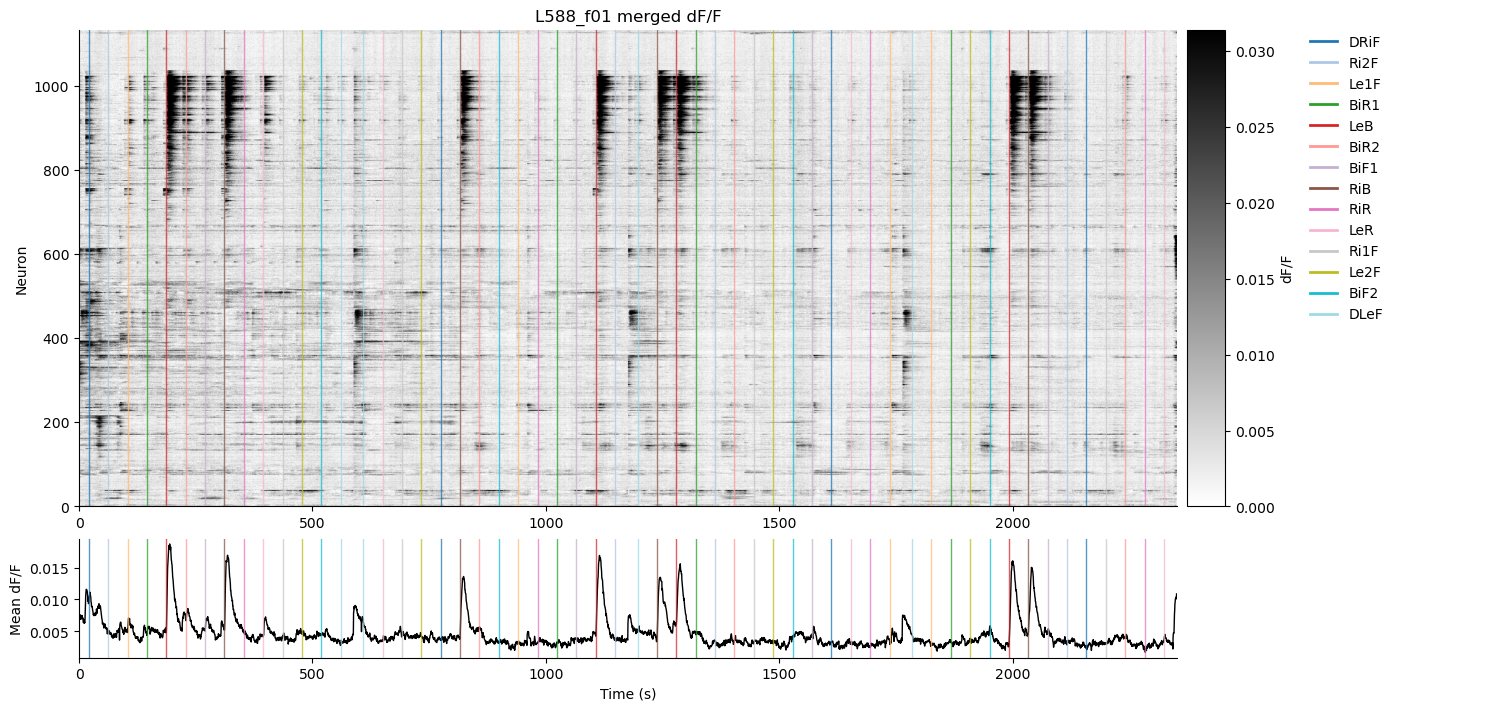

In [13]:
full_figure, full_axes = plot_full_activity(
    dfof=dfof,
    imaging_fps=IMAGING_FPS,
    fish_id=FISH_ID,
    stimulus_events=stimuli["stimulus_events"],
    stimulus_durations=stimuli["stimulus_durations"],
    raster_vmin=RASTER_VMIN,
    raster_vmax=RASTER_VMAX,
    neuron_order=neuron_order,
)
plt.show()

## Cell 06 — Plot concatenated stimulus averages
Average repetitions for each stimulus, concatenate those responses horizontally, and align their all-neuron mean beneath the raster.

{'BiF1': {'found': 4, 'retained': 4, 'dropped': 0}, 'BiF2': {'found': 4, 'retained': 4, 'dropped': 0}, 'BiR1': {'found': 4, 'retained': 4, 'dropped': 0}, 'BiR2': {'found': 4, 'retained': 4, 'dropped': 0}, 'DLeF': {'found': 4, 'retained': 4, 'dropped': 0}, 'DRiF': {'found': 4, 'retained': 4, 'dropped': 0}, 'Le1F': {'found': 4, 'retained': 4, 'dropped': 0}, 'Le2F': {'found': 4, 'retained': 4, 'dropped': 0}, 'LeB': {'found': 4, 'retained': 4, 'dropped': 0}, 'LeR': {'found': 4, 'retained': 4, 'dropped': 0}, 'Ri1F': {'found': 4, 'retained': 4, 'dropped': 0}, 'Ri2F': {'found': 4, 'retained': 4, 'dropped': 0}, 'RiB': {'found': 4, 'retained': 4, 'dropped': 0}, 'RiR': {'found': 4, 'retained': 4, 'dropped': 0}}


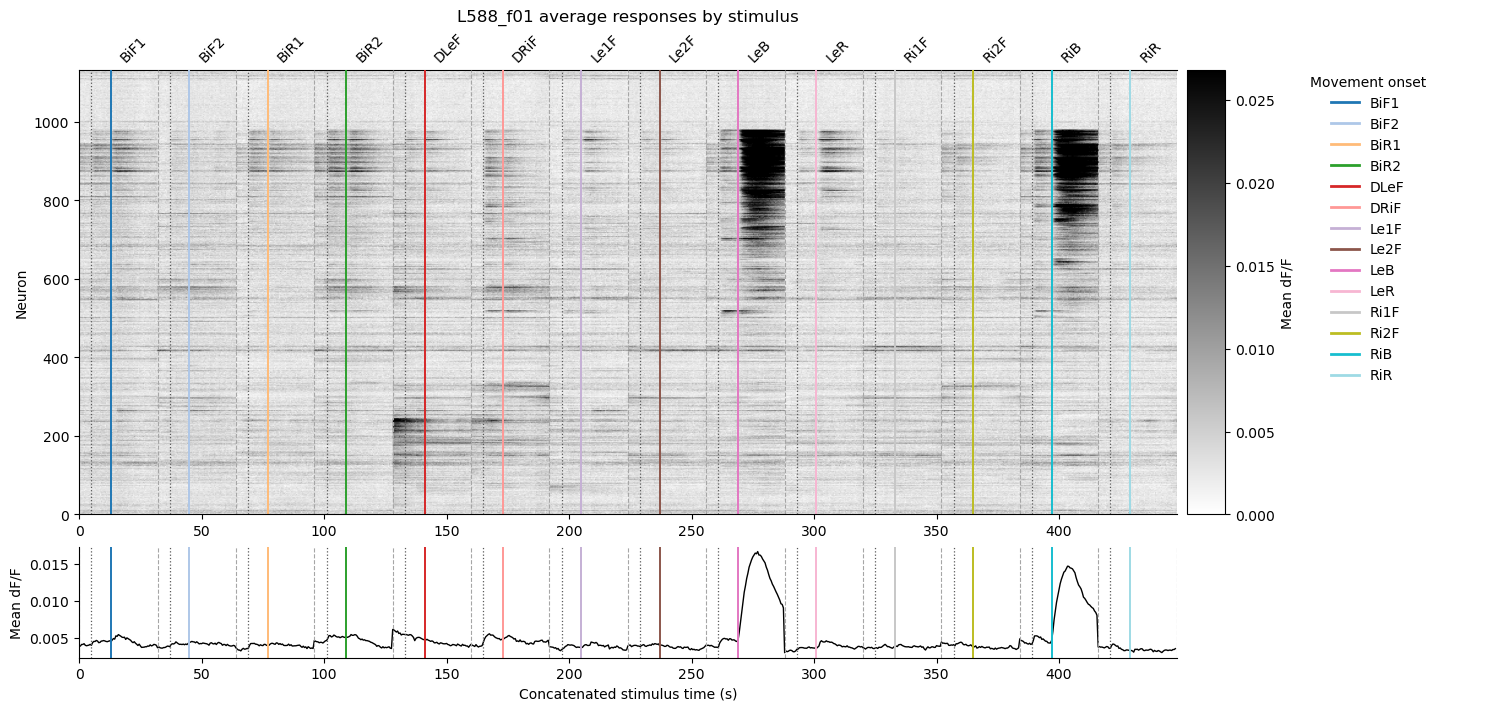

In [14]:
aligned = build_trial_aligned_traces(
    dfof=dfof,
    stimulus_trace=stimuli["stimulus_trace"],
    stimulus_id_map=stimuli["stimulus_id_map"],
    stimulus_durations=stimuli["stimulus_durations"],
    imaging_fps=IMAGING_FPS,
    pre_stimulus_sec=PRE_STIMULUS_SEC,
    post_stimulus_margin_sec=POST_STIMULUS_MARGIN_SEC,
)
print(aligned["trial_counts"])
concatenated_responses = concatenate_stimulus_mean_rasters(
    mean_rasters=aligned["mean_rasters"],
    stimulus_durations=stimuli["stimulus_durations"],
    pre_frames=aligned["pre_frames"],
    imaging_fps=IMAGING_FPS,
    stimulus_order=STIMULUS_ORDER,
)
stimulus_neuron_order = (
    correlation_sort_order(concatenated_responses["raster"].T)
    if SORT_BY_CORRELATION
    else None
)
stimulus_raster_figure, stimulus_raster_axes = plot_concatenated_stimulus_responses(
    concatenated_raster=concatenated_responses["raster"],
    stimulus_segments=concatenated_responses["segments"],
    imaging_fps=IMAGING_FPS,
    fish_id=FISH_ID,
    raster_vmin=RASTER_VMIN,
    raster_vmax=RASTER_VMAX,
    neuron_order=stimulus_neuron_order,
)
plt.show()

## Cell 07 — Plot response metrics
Calculate neuron-level metrics from onset to the end of each stimulus's window (stimulus + margin), then display population mean ± SEM bars.

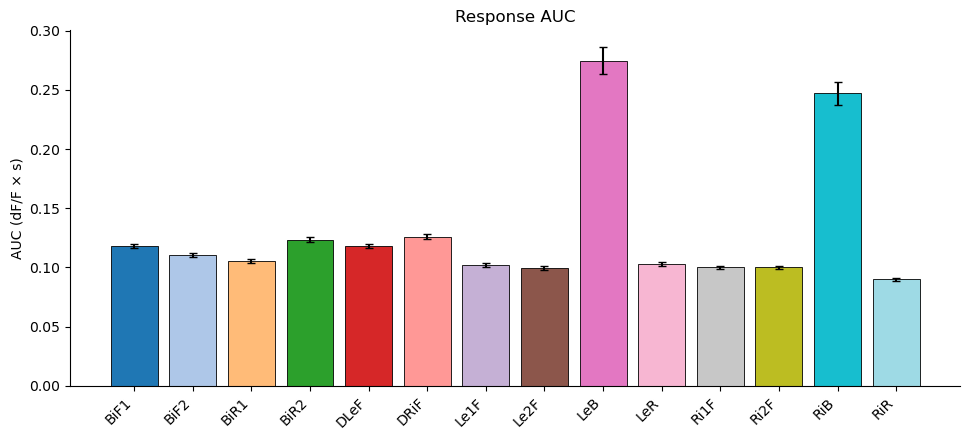

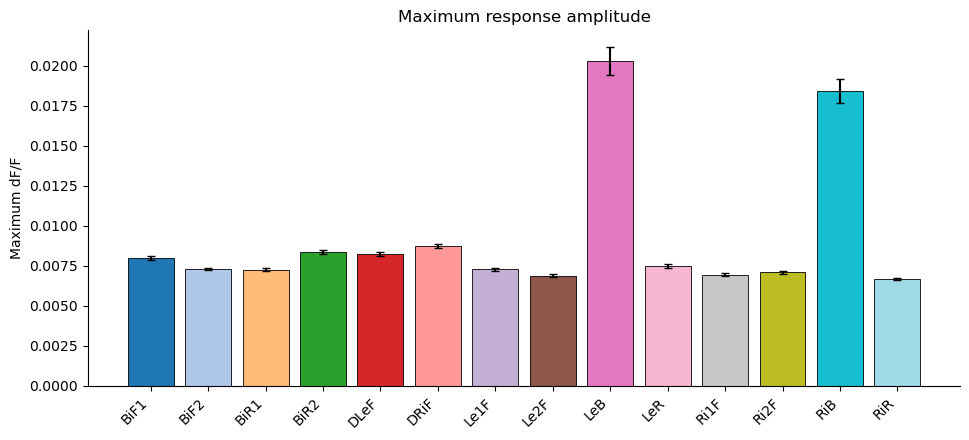

In [15]:
response_metrics = compute_response_metrics(
    mean_rasters=aligned["mean_rasters"],
    pre_frames=aligned["pre_frames"],
    imaging_fps=IMAGING_FPS,
)
auc_summary = summarize_metric(response_metrics["auc"])
maximum_summary = summarize_metric(response_metrics["maximum_amplitude"])
auc_figure, auc_axis = plot_metric_bars(auc_summary, "AUC (dF/F × s)", "Response AUC")
plt.show()
maximum_figure, maximum_axis = plot_metric_bars(maximum_summary, "Maximum dF/F", "Maximum response amplitude")
plt.show()

## Cell 08 — Save the figures
Save PNG copies only when `SAVE_PLOTS` is enabled; existing figures are never overwritten.

In [16]:
saved_paths = []
if SAVE_PLOTS:
    saved_paths.append(save_figure_safely(full_figure, PLOTS_DIR, f"{FISH_ID}_full_activity.png", PLOT_DPI))
    saved_paths.append(save_figure_safely(stimulus_raster_figure, PLOTS_DIR, f"{FISH_ID}_stimulus_rasters.png", PLOT_DPI))
    saved_paths.append(save_figure_safely(auc_figure, PLOTS_DIR, f"{FISH_ID}_stimulus_auc.png", PLOT_DPI))
    saved_paths.append(save_figure_safely(maximum_figure, PLOTS_DIR, f"{FISH_ID}_stimulus_max_amplitude.png", PLOT_DPI))
print("Saved figures:", saved_paths if saved_paths else "saving disabled")

Saved figures: [WindowsPath('C:/Users/suribear/OneDrive - Université de Lausanne/Lab/Data/2p/L588_f01/04_plots/basic_calcium_analysis/L588_f01_full_activity.png'), WindowsPath('C:/Users/suribear/OneDrive - Université de Lausanne/Lab/Data/2p/L588_f01/04_plots/basic_calcium_analysis/L588_f01_stimulus_rasters.png'), WindowsPath('C:/Users/suribear/OneDrive - Université de Lausanne/Lab/Data/2p/L588_f01/04_plots/basic_calcium_analysis/L588_f01_stimulus_auc.png'), WindowsPath('C:/Users/suribear/OneDrive - Université de Lausanne/Lab/Data/2p/L588_f01/04_plots/basic_calcium_analysis/L588_f01_stimulus_max_amplitude.png')]
